# Car Price Prediction

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

## Load Dataset

In [38]:
data = pd.read_csv('dataset/Car_Price_Prediction.csv')

In [39]:
data.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


## Features and Target

In [58]:
X = data.drop(['Price'], axis=1)
X.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission
0,Honda,Model B,2015,3.9,74176,Petrol,Manual
1,Ford,Model C,2014,1.7,94799,Electric,Automatic
2,BMW,Model B,2006,4.1,98385,Electric,Manual
3,Honda,Model B,2015,2.6,88919,Electric,Automatic
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic


In [59]:
y = data['Price']
y.head()

0    30246.207931
1    22785.747684
2    25760.290347
3    25638.003491
4    21021.386657
Name: Price, dtype: float64

## Train-Test Split

In [43]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.25 , shuffle=True)

In [44]:
X_train.shape

(750, 7)

## One-Hot Encoding

In [45]:
categorical_cols = ['Make', 'Model', 'Fuel Type', 'Transmission']
numerical_cols = ['Year', 'Engine Size', 'Mileage']

In [46]:
preprocessor = ColumnTransformer(transformers=[('car', OneHotEncoder(handle_unknown='ignore'), categorical_cols)], remainder='passthrough')

In [47]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

## Lasso Regression Model

In [48]:
lasso_model  = Lasso(alpha=1.0,random_state=33)

## Model Training

In [49]:
lasso_model.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",33
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


## Predictions

In [50]:
y_pred = lasso_model.predict(X_test_encoded)

## Model Evaluation

In [51]:
mse_value = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
mae_value = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')

print(f'MSE Value = {mse_value:.2f}')
print(f'MAE Value = {mae_value:.2f}')

MSE Value = 3800279.29
MAE Value = 1581.94


In [62]:
result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred
})

result.sample(5)

,y_test,y_pred
713,27256.559667,27161.053400
294,27189.626712,29464.638245
113,22734.554676,24316.712435
17,21122.189142,21135.999818
160,26704.096496,26137.586149


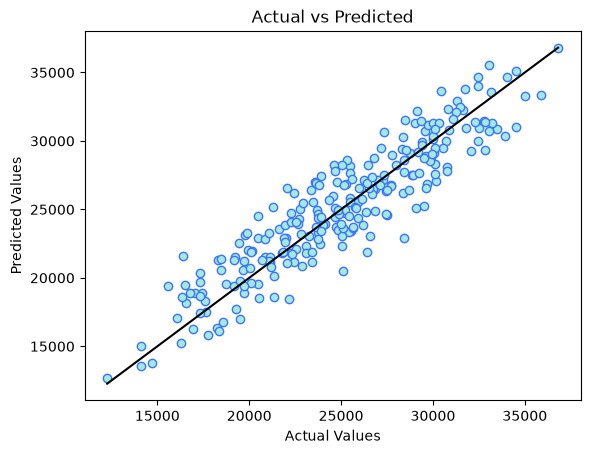

In [53]:
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.scatter(y_test, y_pred, edgecolors='#3874FF' , color='#A5E9DD')
plt.plot([minimum, maximum], [minimum, maximum], color='#000000')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

plt.show()

## Manual Prediction

In [ ]:
make = input('Make: ').strip()
model = input('Model: ').strip().title()
year = int(input('Year: ').strip())
engine_size = float(input('Engine Size: ').strip())
mileage = float(input('Mileage: ').strip())
fuel_type = input('Fuel Type: ').strip().title()
transmission = input('Transmission: ').strip().title()


In [55]:
new_data = pd.DataFrame({
    'Make':[make],
    'Model': [model],
    'Year': [year],
    'Engine Size':[engine_size],
    'Mileage': [mileage],
    'Fuel Type':[fuel_type],
    'Transmission':[transmission]

})
new_data_encoded = preprocessor.transform(new_data)

In [56]:
price = lasso_model.predict(new_data_encoded)
print(f"The predicted price : {price[0]:.2f}$")

The predicted price : 34473.53$


In [57]:
new_data['predicted price'] = price
new_data.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,predicted price
0,Bmw,Model A,2020,3.9,47123.0,Petrol,Automatic,34473.531424
